In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import itertools
import os

In [25]:
# df = pd.read_csv('../reports/python3_report/pairs.csv')
# df.sort_values('similarity', ascending=False, inplace=True)

df = pd.DataFrame()
valid_questions = set(submission["problem_number"] for submission in json.load(open(
        "../data/parsed_submissions.json", "r", encoding="utf-8")))
languages = ["cpp", "c", "csharp", "golang", "java",
                 "javascript", "python", "python3", "rust"]
for question, lang in itertools.product(valid_questions, languages):
    if not os.path.exists(f'../reports/{question}/{lang}_report/pairs.csv'):
        continue
    report_df = pd.read_csv(f'../reports/{question}/{lang}_report/pairs.csv')
    report_df['language'] = lang
    report_df['question'] = question
    report_df['submission_id_left'] = report_df['leftFilePath'].map(lambda x: int(x.split('.')[0].split('/')[-1]))
    report_df['submission_id_right'] = report_df['rightFilePath'].map(lambda x: int(x.split('.')[0].split('/')[-1]))
    df = pd.concat([df, report_df], ignore_index=True)

meta = pd.read_json('../data/parsed_submissions.json')

# meta
df = df.merge(meta[['submission_id', 'user_slug', 'problem_number', 'rank']], left_on='submission_id_left', right_on='submission_id', how='left')
df = df.merge(meta[['submission_id', 'user_slug', 'problem_number', 'rank']], left_on='submission_id_right', right_on='submission_id', how='left', suffixes=('_left_merge', '_right_merge'))
df

,id,leftFileId,leftFilePath,rightFileId,rightFilePath,similarity,totalOverlap,longestFragment,leftCovered,rightCovered,...,submission_id_left,submission_id_right,submission_id_left_merge,user_slug_left_merge,problem_number_left_merge,rank_left_merge,submission_id_right_merge,user_slug_right_merge,problem_number_right_merge,rank_right_merge
0,908,15,submissions/cpp/4410/2124445622.cpp,28,submissions/cpp/4410/2124456976.cpp,0.718447,74,19,37,37,...,2124445622,2124456976,2124445622,undkwxWBze,4410,44,2124456976,rudrapratapsingh11018,4410,98
1,797,9,submissions/cpp/4410/2124445284.cpp,17,submissions/cpp/4410/2124445887.cpp,0.802632,61,11,31,30,...,2124445284,2124445887,2124445284,Kakumaniphaneendra2,4410,34,2124445887,jatin_singh_07,4410,69
2,896,15,submissions/cpp/4410/2124445622.cpp,17,submissions/cpp/4410/2124445887.cpp,0.606742,54,19,27,27,...,2124445622,2124445887,2124445622,undkwxWBze,4410,44,2124445887,jatin_singh_07,4410,69
3,986,26,submissions/cpp/4410/2124451096.cpp,23,submissions/cpp/4410/2124451375.cpp,0.560440,51,8,26,25,...,2124451096,2124451375,2124451096,ankush_rawat1,4410,71,2124451375,jFyYHhFSiP,4410,24
4,877,13,submissions/cpp/4410/2124445438.cpp,25,submissions/cpp/4410/2124452550.cpp,0.547619,46,15,23,23,...,2124445438,2124452550,2124445438,Akshitthakur05,4410,67,2124452550,tejashrip325,4410,91
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3629,838,9,submissions/python3/4380/2124454841.py,15,submissions/python3/4380/2124463641.py,0.000000,0,0,0,0,...,2124454841,2124463641,2124454841,ayush_learner018,4380,54,2124463641,anassharafat,4380,35
3630,844,9,submissions/python3/4380/2124454841.py,18,submissions/python3/4380/2124468811.py,0.000000,0,0,0,0,...,2124454841,2124468811,2124454841,ayush_learner018,4380,54,2124468811,puranjai_26,4380,59
3631,845,9,submissions/python3/4380/2124454841.py,21,submissions/python3/4380/2124469207.py,0.000000,0,0,0,0,...,2124454841,2124469207,2124454841,ayush_learner018,4380,54,2124469207,lohi_17,4380,60
3632,911,16,submissions/python3/4380/2124465526.py,20,submissions/python3/4380/2124466226.py,0.000000,0,0,0,0,...,2124465526,2124466226,2124465526,undkwxWBze,4380,44,2124466226,PRASAANTHGT2003,4380,47


In [26]:
df_cleaned = df[df['similarity'] > 0]

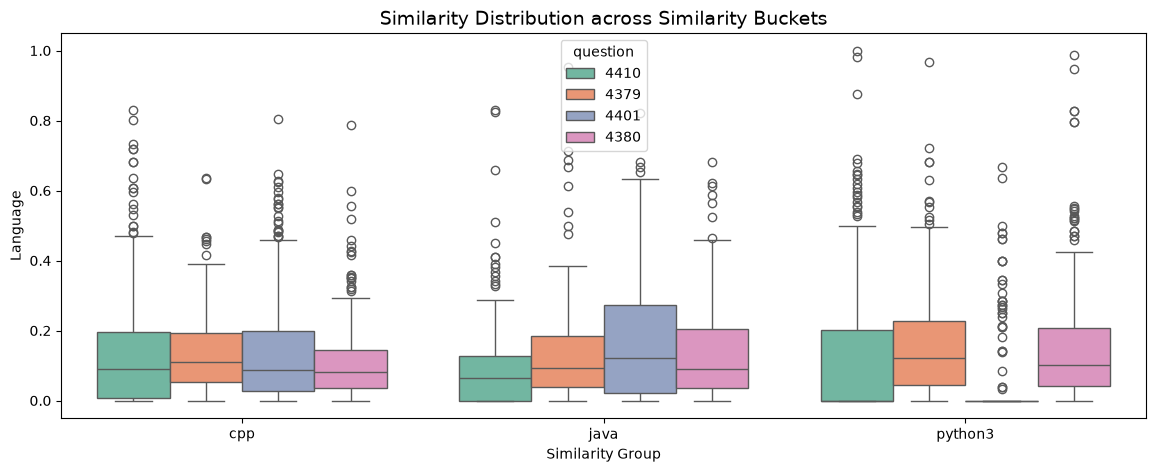

In [27]:
plt.figure(figsize=(14, 5))
sns.boxplot(data=df, x='language', y='similarity', hue='question', palette='Set2')

plt.title('Similarity Distribution across Similarity Buckets', fontsize=14)
plt.xlabel('Similarity Group')
plt.ylabel('Language')
plt.show()
